# Automatic recognition of objects/people in the image

**Author:** *Corneliu Catlabuga*

**Group:** *IS-251M*

In [ ]:
import tensorflow as tf
import kagglehub as kh
from keras import layers, models
from matplotlib import pyplot as plt


# Ensure GPU is recognized
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [17]:
ds_path = kh.dataset_download("marquis03/flower-classification")

Using Colab cache for faster access to the 'flower-classification' dataset.


In [18]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    f"{ds_path}/train",
    image_size=(150,150)
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    f"{ds_path}/val",
    image_size=(150,150)
)

num_classes = len(train_dataset.class_names)

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.


In [19]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.2),

    layers.Dense(512, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [20]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 148, 148, 32)   │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 74, 74, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14)             │         7,182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,040,974 (72.64 MB)

 Trainable params: 19,040,910 (72.64 MB)

 Non-trainable params: 64 (256.00 B)

In [21]:
# Compiling your model [cite: 26]
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset
)

Epoch 1/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.0748 - loss: 2.8734 - val_accuracy: 0.0714 - val_loss: 2.6419
Epoch 2/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.0754 - loss: 2.6366 - val_accuracy: 0.0918 - val_loss: 2.6423
Epoch 3/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.2605 - loss: 2.1412 - val_accuracy: 0.3571 - val_loss: 1.7101
Epoch 4/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.4579 - loss: 1.5633 - val_accuracy: 0.5102 - val_loss: 1.5541
Epoch 5/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.5312 - loss: 1.3683 - val_accuracy: 0.3673 - val_loss: 3.4973
Epoch 6/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.5816 - loss: 1.2238 - val_accuracy: 0.0918 - val_loss: 7.6859
Epoch 7/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.6330 - loss: 1.0858 - val_accuracy: 0.5510 - val_loss: 1.3148
Epoch 8/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.6642 - loss: 0.9905 - 

In [23]:
model.save('flowers.keras')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7653 - loss: 0.9135
Validation Loss: 0.9135
Validation Accuracy: 0.7653


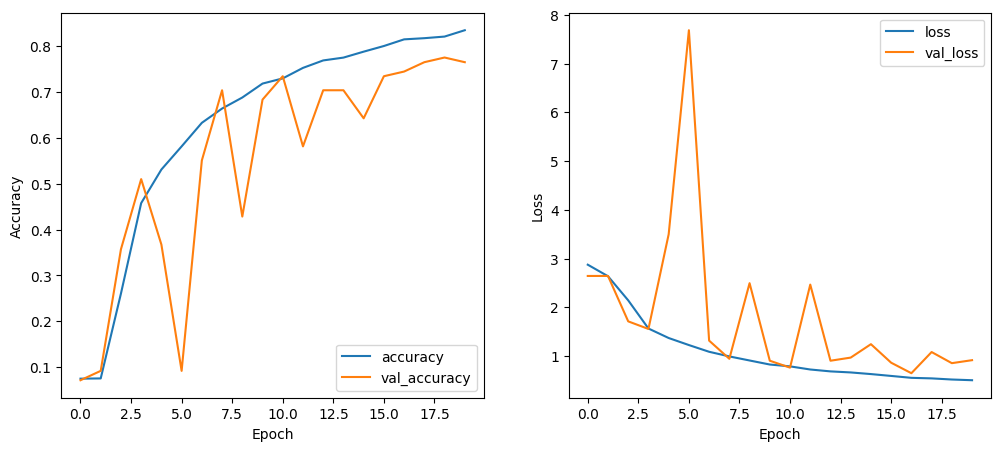

In [25]:
loss, accuracy = model.evaluate(val_dataset)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')